# Task 4: Ensemble Learning
**Objective:** Train ensemble models utilizing cluster labels, compare with the baseline model, and analyze feature importance.
**Inputs:** `../data/clustered.csv`, `../models/supervised_best.pkl`
**Outputs:** `../models/ensemble_best.pkl`

In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from scipy.sparse import hstack

df = pd.read_csv('../data/clustered.csv')

X_text = df['Translated_Review'].astype(str)
y = df['Sentiment']

tfidf = TfidfVectorizer(max_features=500)
X_tfidf = tfidf.fit_transform(X_text)

scaler = StandardScaler()
X_num = scaler.fit_transform(df[['Review_Word_Count', 'Review_Char_Count', 'cluster_label']])

X = hstack((X_tfidf, X_num)).toarray()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Train Ensemble Models
**Action:** Train Random Forest and Gradient Boosting classifiers.

In [2]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
acc_gb = accuracy_score(y_test, y_pred_gb)

print(f"Random Forest Accuracy: {acc_rf:.4f}")
print(f"Gradient Boosting Accuracy: {acc_gb:.4f}")

Random Forest Accuracy: 0.8271
Gradient Boosting Accuracy: 0.8040


### Model Comparison
**Action:** Load the best model from Task 2, evaluate it on the appropriate feature set, and compare.

In [3]:
with open('../models/supervised_best.pkl', 'rb') as f:
    best_t2_model = pickle.load(f)

X_num_t2 = scaler.fit_transform(df[['Review_Word_Count', 'Review_Char_Count']])
X_t2 = hstack((X_tfidf, X_num_t2))
_, X_test_t2, _, _ = train_test_split(X_t2, y, test_size=0.2, random_state=42)

y_pred_t2 = best_t2_model.predict(X_test_t2)
acc_t2 = accuracy_score(y_test, y_pred_t2)

print(f"Task 2 Best Model Accuracy: {acc_t2:.4f}")
print(f"Improvement (RF vs T2): {acc_rf - acc_t2:.4f}")

best_ensemble = rf if acc_rf > acc_gb else gb
with open('../models/ensemble_best.pkl', 'wb') as f:
    pickle.dump(best_ensemble, f)

Task 2 Best Model Accuracy: 0.8528
Improvement (RF vs T2): -0.0258


### Feature Importance
**Action:** Extract and plot the top 10 most important features from the Random Forest model.

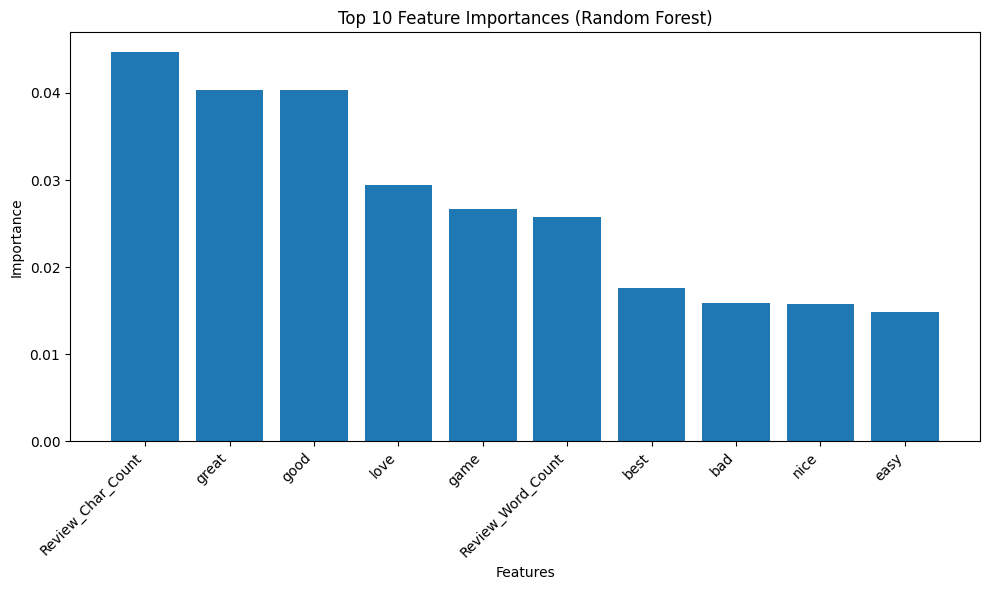

In [4]:
feature_names = np.array(tfidf.get_feature_names_out().tolist() + ['Review_Word_Count', 'Review_Char_Count', 'cluster_label'])
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.bar(range(10), importances[indices], align="center")
plt.xticks(range(10), feature_names[indices], rotation=45, ha='right')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', bbox_inches='tight')
plt.show()

#### Raw text vectors (TF-IDF) and basic text statistics were more than sufficient for accurate classification by the Random Forest model, so cluster labels lost predictive value in the presence of strong keywords.